<a href="https://colab.research.google.com/github/Avalya/Unified-PINN-Virtual-Sensors/blob/main/robot_robot_pinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-Informed Neural Network (PINN) for Mobile Robot Trajectory Reconstruction

This notebook implements a Physics-Informed Neural Network (PINN) to reconstruct the trajectory of a mobile robot. The PINN leverages both available data points and the underlying differential kinematic equations of the robot to accurately interpolate missing data segments (data gaps) and enforce physical consistency.

## 1. Setup and Data Loading

This section imports necessary libraries, defines physical constants for the robot, and handles the loading and preprocessing of the trajectory data. Critical steps include data normalization, separation of training and reconstruction sets, and storing scaling parameters for later denormalization and physics loss calculations. It also defines a utility function for calculating NRMSE.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import os

# Define physical constants for the robot
r = 0.022  # meters (wheel radius) - not used in current physics loss, but kept for context
B = 0.161  # meters (robot base width) - not used in current physics loss, but kept for context

# Ensure the data file is present. User needs to upload 'pinn-data.csv' to /content/
file_path = '/content/pinn-data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Please upload '{os.path.basename(file_path)}' to {os.path.dirname(file_path)} before running this cell.")

# Load the CSV file
df = pd.read_csv(file_path)

# Select and rename columns for consistency and easier access
df = df[['Timestamp (t)', 'X-coordinate', 'Y-coordinate', 'Theta (radians)', 'Is_training']]
df.columns = ['Timestamp', 'X-coordinate', 'Y-coordinate', 'Theta', 'is_training']

# Store original raw time for later use in plotting and NRMSE calculation
t_raw = df['Timestamp'].values.astype(np.float32)

# --- Manual MinMaxScaler and Storage of Scale Parameters ---
# This is crucial for correctly scaling inputs/outputs and derivatives
scale_params = {}
for col in ['Timestamp', 'X-coordinate', 'Y-coordinate', 'Theta']:
    raw_values = df[col].values.astype(np.float32)
    # Handle potential NaNs for min/max calculation by ignoring them
    min_val = np.nanmin(raw_values) if not np.all(np.isnan(raw_values)) else 0.0 # Handle all NaN case
    max_val = np.nanmax(raw_values) if not np.all(np.isnan(raw_values)) else 1.0 # Handle all NaN case

    # If min == max, set range to 1 to avoid division by zero (e.g., for constant values)
    if min_val == max_val:
        range_val = 1.0
    else:
        range_val = max_val - min_val

    scale_params[col] = {'min': min_val, 'max': max_val, 'range': range_val}

    # Normalize non-NaN values in the DataFrame
    # Create a new column for normalized values
    df[f'{col}_normalized'] = np.nan  # Initialize with NaN

    # Apply normalization only to non-NaN values
    non_nan_mask = ~np.isnan(raw_values)
    df.loc[non_nan_mask, f'{col}_normalized'] = (raw_values[non_nan_mask] - min_val) / range_val

# Store scale factors for denormalization and physics loss (chain rule)
scale_params['X_scale_factor'] = scale_params['X-coordinate']['range']
scale_params['Y_scale_factor'] = scale_params['Y-coordinate']['range']
scale_params['Theta_scale_factor'] = scale_params['Theta']['range']
scale_params['t_scale_factor'] = scale_params['Timestamp']['range']

# Prepare data for PyTorch tensors (normalized inputs)
t_all_normalized = torch.tensor(df['Timestamp_normalized'].values, dtype=torch.float32).unsqueeze(1)

# Separate training and reconstruction data masks
training_mask = df['is_training'] == True
reconstruction_mask = df['is_training'] == False

# Training data (ground truth points) - using normalized coordinates
# Ensure only non-NaN values for X, Y, Theta are used for training data
valid_training_mask = training_mask & ~df['X-coordinate_normalized'].isna() & ~df['Y-coordinate_normalized'].isna() & ~df['Theta_normalized'].isna()

t_train = torch.tensor(df.loc[valid_training_mask, 'Timestamp_normalized'].values, dtype=torch.float32).unsqueeze(1)
X_train = torch.tensor(df.loc[valid_training_mask, 'X-coordinate_normalized'].values, dtype=torch.float32).unsqueeze(1)
Y_train = torch.tensor(df.loc[valid_training_mask, 'Y-coordinate_normalized'].values, dtype=torch.float32).unsqueeze(1)
Theta_train = torch.tensor(df.loc[valid_training_mask, 'Theta_normalized'].values, dtype=torch.float32).unsqueeze(1)

print("Data loaded and preprocessed.")
print(f"Total data points: {len(df)}")
print(f"Training data points: {len(X_train)}")
print(f"Reconstruction data points: {reconstruction_mask.sum()}")

# --- NRMSE Function ---
def calculate_nrmse(y_true, y_pred):
    """Calculates Normalized Root Mean Squared Error (NRMSE) as a percentage."""
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    range_y = np.max(y_true) - np.min(y_true)
    if range_y == 0:
        return 0.0 # Handle cases where range is zero to avoid division by zero
    return rmse / range_y * 100 # Return as percentage

Data loaded and preprocessed.
Total data points: 25
Training data points: 15
Reconstruction data points: 10


## 2. PINN Model Definition

This section defines the architecture of our Physics-Informed Neural Network. It includes a custom `Sine` activation function, which is often beneficial for PINNs dealing with oscillatory phenomena, and a multi-layer perceptron with Xavier Uniform initialization for stable training. As specified in the problem, the model uses 8 hidden layers, each with 128 neurons.

In [ ]:
class Sine(nn.Module):
    """Custom Sine activation function."""
    def forward(self, input):
        return torch.sin(input)

class PINN(nn.Module):
    """Physics-Informed Neural Network model architecture."""
    def __init__(self):
        super(PINN, self).__init__()
        # 8 hidden layers with 128 neurons each
        self.net = nn.Sequential(
            nn.Linear(1, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 3) # Output: x_norm, y_norm, theta_norm
        )
        # Apply Xavier Uniform initialization for better convergence
        self.apply(self._init_weights)

    def _init_weights(self, module):
        """Initializes weights using Xavier Uniform distribution."""
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(self, t):
        """Forward pass through the network."""
        return self.net(t)

print("PINN model defined with Sine activation and Xavier Uniform initialization.")

PINN model defined with Sine activation and Xavier Uniform initialization.


## 3. Training Loop with Physics Loss

This cell defines the core `train_pinn_model` function, incorporating both a data loss (Mean Squared Error on known ground truth points) and a physics loss. The physics loss enforces the robot's differential kinematic equations, ensuring physical consistency of the reconstructed trajectory. Crucially, the derivatives in the physics loss are correctly scaled using the chain rule. The `scale_parameters` dictionary is passed to ensure all scaling is handled consistently.

In [ ]:
def train_pinn_model(model, t_train_data, X_train_data, Y_train_data, Theta_train_data, t_physics_data, scale_parameters, epochs, initial_lambda_physics, final_lambda_physics, annealing_epochs_ratio, lr):
    """Trains the PINN model using Adam optimizer with data and physics losses, with linear annealing for lambda_physics."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse_loss_fn = nn.MSELoss()

    total_losses_hist = []
    data_losses_hist = []
    physics_losses_hist = []

    # Extract scale factors from the dictionary for clarity and efficiency
    t_scale_factor = scale_parameters['t_scale_factor']
    x_scale_factor = scale_parameters['X_scale_factor']
    y_scale_factor = scale_parameters['Y_scale_factor']
    theta_scale_factor = scale_parameters['Theta_scale_factor']

    x_min = scale_parameters['X-coordinate']['min']
    y_min = scale_parameters['Y-coordinate']['min']
    theta_min = scale_parameters['Theta']['min']

    print(f"Starting training with lr={lr}, initial_lambda_physics={initial_lambda_physics}, final_lambda_physics={final_lambda_physics} for {epochs} epochs...")
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Calculate annealed lambda_physics
        if epochs > 1 and annealing_epochs_ratio > 0:
            annealing_point = int(epochs * annealing_epochs_ratio)
            if annealing_point == 0: annealing_point = 1 # Ensure division by zero is avoided for very small epochs
            current_lambda_physics = initial_lambda_physics + (final_lambda_physics - initial_lambda_physics) * min(1.0, epoch / annealing_point)
        else:
            current_lambda_physics = initial_lambda_physics # Fallback to static if no annealing

        # 1. Data Loss (MSE on known ground truth points)
        predictions_train_norm = model(t_train_data)
        x_pred_train_norm, y_pred_train_norm, theta_pred_train_norm = predictions_train_norm[:, 0:1], predictions_train_norm[:, 1:2], predictions_train_norm[:, 2:3]

        loss_data_x = mse_loss_fn(x_pred_train_norm, X_train_data)
        loss_data_y = mse_loss_fn(y_pred_train_norm, Y_train_data)
        loss_data_theta = mse_loss_fn(theta_pred_train_norm, Theta_train_data)
        loss_data = loss_data_x + loss_data_y + loss_data_theta

        # 2. Physics Loss (enforcing kinematic equations)
        # Get normalized predictions from the model for all time points (t_physics_data)
        # t_physics_data must have requires_grad=True
        predictions_physics_norm = model(t_physics_data)
        x_physics_norm, y_physics_norm, theta_physics_norm = predictions_physics_norm[:, 0:1], predictions_physics_norm[:, 1:2], predictions_physics_norm[:, 2:3]

        # Denormalize x, y, theta to real-world units for physics calculations
        x_physics_real = x_physics_norm * x_scale_factor + x_min
        y_physics_real = y_physics_norm * y_scale_factor + y_min
        theta_physics_real = theta_physics_norm * theta_scale_factor + theta_min

        # Calculate derivatives of real-world x, y with respect to normalized time t_physics_data
        # d(output_real)/d(t_norm)
        dx_dt_real_intermediate = grad(x_physics_real, t_physics_data, torch.ones_like(x_physics_real), create_graph=True, retain_graph=True)[0]
        dy_dt_real_intermediate = grad(y_physics_real, t_physics_data, torch.ones_like(y_physics_real), create_graph=True, retain_graph=True)[0]

        # Apply the chain rule correction to get d(output_real)/d(t_real) (physical units)
        # d(t_norm)/d(t_real) = 1 / t_scale_factor
        dx_phys = dx_dt_real_intermediate / t_scale_factor
        dy_phys = dy_dt_real_intermediate / t_scale_factor

        # Calculate 'v' (velocity magnitude) from predicted dx_phys and dy_phys
        v_phys = torch.sqrt(dx_phys**2 + dy_phys**2)

        # Calculate residuals based on kinematic equations: x_dot = v*cos(theta), y_dot = v*sin(theta)
        residual_x = dx_phys - v_phys * torch.cos(theta_physics_real)
        residual_y = dy_phys - v_phys * torch.sin(theta_physics_real)

        # Physics loss as mean of squared residuals
        loss_physics = torch.mean(residual_x**2 + residual_y**2)

        # Total Loss: combination of data and physics losses
        loss = loss_data + current_lambda_physics * loss_physics # Use annealed lambda_physics

        loss.backward()
        optimizer.step()

        total_losses_hist.append(loss.item())
        data_losses_hist.append(loss_data.item())
        physics_losses_hist.append(loss_physics.item())

        if (epoch + 1) % 100 == 0:
            print(f'Epoch {epoch + 1}/{epochs}, Total Loss: {loss.item():.6f}, Data Loss: {loss_data.item():.6f}, Physics Loss: {loss_physics.item():.6f}, Lambda Physics: {current_lambda_physics:.4f}')

    print(f"Training finished for lr={lr}, final_lambda_physics={current_lambda_physics}.")
    return model, total_losses_hist, data_losses_hist, physics_losses_hist

## 4. Two-phase Optimization Execution (Adam + L-BFGS)

To achieve better convergence and fine-tune the model, a two-phase optimization strategy is employed. First, the Adam optimizer is used for a set number of epochs to quickly reduce the overall loss. This is followed by the L-BFGS optimizer, known for its efficiency in converging to local minima for small-scale problems, which further refines the model parameters.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad
import os
from scipy.interpolate import interp1d

# --- Data Loading and Preprocessing (Copied from cell 5681f7e8 for robustness) ---
# Define physical constants for the robot
r = 0.022  # meters (wheel radius) - not used in current physics loss, but kept for context
B = 0.161  # meters (robot base width) - not used in current physics loss, but kept for context

# Ensure the data file is present. User needs to upload 'pinn-data.csv' to /content/
file_path = '/content/pinn-data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Please upload '{os.path.basename(file_path)}' to {os.path.dirname(file_path)} before running this cell.")

# Load the CSV file
df = pd.read_csv(file_path)

# Select and rename columns for consistency and easier access
df = df[['Timestamp (t)', 'X-coordinate', 'Y-coordinate', 'Theta (radians)', 'Is_training']]
df.columns = ['Timestamp', 'X-coordinate', 'Y-coordinate', 'Theta', 'is_training']

# Store original raw time for later use in plotting and NRMSE calculation
t_raw = df['Timestamp'].values.astype(np.float32)

# --- Manual MinMaxScaler and Storage of Scale Parameters ---
# This is crucial for correctly scaling inputs/outputs and derivatives
scale_params = {}
for col in ['Timestamp', 'X-coordinate', 'Y-coordinate', 'Theta']:
    raw_values = df[col].values.astype(np.float32)
    # Handle potential NaNs for min/max calculation by ignoring them
    min_val = np.nanmin(raw_values) if not np.all(np.isnan(raw_values)) else 0.0 # Handle all NaN case
    max_val = np.nanmax(raw_values) if not np.all(np.isnan(raw_values)) else 1.0 # Handle all NaN case

    # If min == max, set range to 1 to avoid division by zero (e.g., for constant values)
    if min_val == max_val:
        range_val = 1.0
    else:
        range_val = max_val - min_val

    scale_params[col] = {'min': min_val, 'max': max_val, 'range': range_val}

    # Normalize non-NaN values in the DataFrame
    # Create a new column for normalized values
    df[f'{col}_normalized'] = np.nan  # Initialize with NaN

    # Apply normalization only to non-NaN values
    non_nan_mask = ~np.isnan(raw_values)
    df.loc[non_nan_mask, f'{col}_normalized'] = (raw_values[non_nan_mask] - min_val) / range_val

# Store scale factors for denormalization and physics loss (chain rule)
scale_params['X_scale_factor'] = scale_params['X-coordinate']['range']
scale_params['Y_scale_factor'] = scale_params['Y-coordinate']['range']
scale_params['Theta_scale_factor'] = scale_params['Theta']['range']
scale_params['t_scale_factor'] = scale_params['Timestamp']['range']

# Prepare data for PyTorch tensors (normalized inputs)
t_all_normalized = torch.tensor(df['Timestamp_normalized'].values, dtype=torch.float32).unsqueeze(1)

# Separate training and reconstruction data masks
training_mask = df['is_training'] == True
reconstruction_mask = df['is_training'] == False

# Training data (ground truth points) - using normalized coordinates
# Ensure only non-NaN values for X, Y, Theta are used for training data
valid_training_mask = training_mask & ~df['X-coordinate_normalized'].isna() & ~df['Y-coordinate_normalized'].isna() & ~df['Theta_normalized'].isna()

t_train = torch.tensor(df.loc[valid_training_mask, 'Timestamp_normalized'].values, dtype=torch.float32).unsqueeze(1)
X_train = torch.tensor(df.loc[valid_training_mask, 'X-coordinate_normalized'].values, dtype=torch.float32).unsqueeze(1)
Y_train = torch.tensor(df.loc[valid_training_mask, 'Y-coordinate_normalized'].values, dtype=torch.float32).unsqueeze(1)
Theta_train = torch.tensor(df.loc[valid_training_mask, 'Theta_normalized'].values, dtype=torch.float32).unsqueeze(1)

print("Data loaded and preprocessed for Two-phase Optimization Execution.")
# --- End of Data Loading and Preprocessing ---

# Instantiate the model for training
model = PINN()

# --- Adam Phase ---
adam_epochs = 1000
adam_lr = 1e-3

# New annealing parameters as per user request
initial_lambda_physics_adam = 0.01
final_lambda_physics_adam = 0.1
annealing_epochs_ratio_adam = 0.8  # Anneal over 80% of Adam epochs

# Clone t_all_normalized for physics points and set requires_grad=True
t_physics_adam = t_all_normalized.clone().detach().requires_grad_(True)

print("\n--- Starting Adam optimization phase ---")
model, adam_total_losses, adam_data_losses, adam_physics_losses = \
    train_pinn_model(model, t_train, X_train, Y_train, Theta_train, t_physics_adam,
                     scale_params, adam_epochs, initial_lambda_physics_adam, final_lambda_physics_adam, annealing_epochs_ratio_adam, adam_lr)

print("Adam optimization finished.")

# --- L-BFGS Phase ---
lbfgs_max_iter = 50000  # Increased as per user request

print("\n--- Starting L-BFGS optimization phase ---")
# Prepare t_physics for L-BFGS, ensuring it has requires_grad=True
t_physics_lbfgs = t_all_normalized.clone().detach().requires_grad_(True)

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_max_iter, history_size=100, line_search_fn="strong_wolfe")

# Initialize lists to store L-BFGS specific losses
lbfgs_total_losses = []
lbfgs_data_losses = []
lbfgs_physics_losses = []

def closure():
    """Closure function for L-BFGS optimizer, calculating total loss."""
    optimizer_lbfgs.zero_grad()

    # 1. Data Loss
    predictions_train_norm = model(t_train)
    x_pred_train_norm, y_pred_train_norm, theta_pred_train_norm = predictions_train_norm[:, 0:1], predictions_train_norm[:, 1:2], predictions_train_norm[:, 2:3]

    loss_data_x = nn.MSELoss()(x_pred_train_norm, X_train)
    loss_data_y = nn.MSELoss()(y_pred_train_norm, Y_train)
    loss_data_theta = nn.MSELoss()(theta_pred_train_norm, Theta_train)
    loss_data = loss_data_x + loss_data_y + loss_data_theta

    # 2. Physics Loss
    predictions_physics_norm = model(t_physics_lbfgs)
    x_physics_norm, y_physics_norm, theta_physics_norm = predictions_physics_norm[:, 0:1], predictions_physics_norm[:, 1:2], predictions_physics_norm[:, 2:3]

    # Denormalize for physics calculations
    x_physics_real = x_physics_norm * scale_params['X_scale_factor'] + scale_params['X-coordinate']['min']
    y_physics_real = y_physics_norm * scale_params['Y_scale_factor'] + scale_params['Y-coordinate']['min']
    theta_physics_real = theta_physics_norm * scale_params['Theta_scale_factor'] + scale_params['Theta']['min']

    dx_dt_real_intermediate = grad(x_physics_real, t_physics_lbfgs, torch.ones_like(x_physics_real), create_graph=True, retain_graph=True)[0]
    dy_dt_real_intermediate = grad(y_physics_real, t_physics_lbfgs, torch.ones_like(y_physics_real), create_graph=True, retain_graph=True)[0]

    dx_phys = dx_dt_real_intermediate / scale_params['t_scale_factor']
    dy_phys = dy_dt_real_intermediate / scale_params['t_scale_factor']

    v_phys = torch.sqrt(dx_phys**2 + dy_phys**2)

    residual_x = dx_phys - v_phys * torch.cos(theta_physics_real)
    residual_y = dy_phys - v_phys * torch.sin(theta_physics_real)

    loss_physics = torch.mean(residual_x**2 + residual_y**2)

    # Total Loss (using the final lambda_physics from the Adam phase for consistency)
    total_loss = loss_data + final_lambda_physics_adam * loss_physics

    # Store L-BFGS losses for plotting (only if called directly, L-BFGS optimizes without explicit epochs)
    lbfgs_total_losses.append(total_loss.item())
    lbfgs_data_losses.append(loss_data.item())
    lbfgs_physics_losses.append(loss_physics.item())

    total_loss.backward()
    return total_loss

optimizer_lbfgs.step(closure)

print("L-BFGS optimization finished.")

# Combine Adam and L-BFGS loss histories for plotting
all_total_losses = adam_total_losses + lbfgs_total_losses
all_data_losses = adam_data_losses + lbfgs_data_losses
all_physics_losses = adam_physics_losses + lbfgs_physics_losses

Data loaded and preprocessed for Two-phase Optimization Execution.

--- Starting Adam optimization phase ---
Starting training with lr=0.001, initial_lambda_physics=0.01, final_lambda_physics=0.1 for 1000 epochs...
Epoch 100/1000, Total Loss: 0.081239, Data Loss: 0.081239, Physics Loss: 0.000004, Lambda Physics: 0.0211
Epoch 200/1000, Total Loss: 0.081163, Data Loss: 0.081163, Physics Loss: 0.000004, Lambda Physics: 0.0324
Epoch 300/1000, Total Loss: 0.080653, Data Loss: 0.080653, Physics Loss: 0.000004, Lambda Physics: 0.0436
Epoch 400/1000, Total Loss: 0.081100, Data Loss: 0.081100, Physics Loss: 0.000004, Lambda Physics: 0.0549
Epoch 500/1000, Total Loss: 0.075137, Data Loss: 0.075136, Physics Loss: 0.000014, Lambda Physics: 0.0661
Epoch 600/1000, Total Loss: 0.081052, Data Loss: 0.081052, Physics Loss: 0.000004, Lambda Physics: 0.0774
Epoch 700/1000, Total Loss: 0.080266, Data Loss: 0.080265, Physics Loss: 0.000004, Lambda Physics: 0.0886
Epoch 800/1000, Total Loss: 0.060646, Data 

## 5. Hyperparameter Tuning (Grid Search)

This section performs a hyperparameter grid search to find optimal `lambda_physics` and learning rate values. For each combination, a new PINN model is trained, and its final loss is recorded. This systematic search helps in identifying the best performing set of parameters for the given problem.

In [ ]:
# Define hyperparameter search space
lambda_physics_values = [0.001, 0.01, 0.1]
lr_values = [1e-4, 1e-3, 1e-2]

best_loss = float('inf')
best_params = {}

results = []

print("\n--- Starting Hyperparameter Grid Search ---")

# Ensure t_physics has requires_grad=True for the grid search
t_physics_grid_search = t_all_normalized.clone().detach().requires_grad_(True)

# Using the adam_epochs from the previous section for consistency in grid search training duration
grid_search_epochs = adam_epochs

for current_lr in lr_values:
    for current_lambda_physics in lambda_physics_values:
        print(f"\n--- Training with lr={current_lr}, lambda_physics={current_lambda_physics} ---")

        # Instantiate a fresh model for each run to avoid transfer learning effects
        model_grid_search = PINN()

        # Corrected call to train_pinn_model with all required arguments
        trained_model, total_losses_hist, data_losses_hist, physics_losses_hist = \
            train_pinn_model(model_grid_search, t_train, X_train, Y_train, Theta_train, t_physics_grid_search,
                             scale_params, grid_search_epochs, current_lambda_physics, current_lambda_physics, 0, current_lr)

        final_loss = total_losses_hist[-1]
        results.append({
            'lr': current_lr,
            'lambda_physics': current_lambda_physics,
            'final_total_loss': final_loss,
            'model': trained_model # Store the trained model if needed for later analysis
        })

        if final_loss < best_loss:
            best_loss = final_loss
            best_params = {
                'lr': current_lr,
                'lambda_physics': current_lambda_physics,
                'final_total_loss': final_loss,
                'model': trained_model # Store the best model
            }

print("\nHyperparameter Grid Search Finished.")
print(f"Best parameters found: {best_params}")

# Now, use the best model found for subsequent evaluation
if 'model' in best_params:
    final_trained_model = best_params['model']
    print("Using the best model from grid search for evaluation.")
else:
    final_trained_model = model # Fallback to the model trained in two-phase optimization
    print("No best model from grid search, falling back to the model from two-phase optimization.")


--- Starting Hyperparameter Grid Search ---

--- Training with lr=0.0001, lambda_physics=0.001 ---
Starting training with lr=0.0001, initial_lambda_physics=0.001, final_lambda_physics=0.001 for 1000 epochs...
Epoch 100/1000, Total Loss: 0.081400, Data Loss: 0.081400, Physics Loss: 0.000004, Lambda Physics: 0.0010
Epoch 200/1000, Total Loss: 0.081179, Data Loss: 0.081179, Physics Loss: 0.000004, Lambda Physics: 0.0010
Epoch 300/1000, Total Loss: 0.081171, Data Loss: 0.081171, Physics Loss: 0.000004, Lambda Physics: 0.0010
Epoch 400/1000, Total Loss: 0.081161, Data Loss: 0.081161, Physics Loss: 0.000004, Lambda Physics: 0.0010
Epoch 500/1000, Total Loss: 0.081149, Data Loss: 0.081149, Physics Loss: 0.000004, Lambda Physics: 0.0010
Epoch 600/1000, Total Loss: 0.081132, Data Loss: 0.081132, Physics Loss: 0.000004, Lambda Physics: 0.0010
Epoch 700/1000, Total Loss: 0.081110, Data Loss: 0.081110, Physics Loss: 0.000004, Lambda Physics: 0.0010
Epoch 800/1000, Total Loss: 0.081080, Data Loss:

## 6. Evaluation and Visualization

This section evaluates the trained PINN model's performance. It calculates the Normalized Root Mean Squared Error (NRMSE) for both known data points and the reconstructed data gap. Several plots are generated to visualize:

1.  The convergence of the data, physics, and total losses during training.
2.  The 2D robot trajectory, comparing ground truth with PINN's reconstruction.
3.  The magnitude of the physics residual over time, indicating where the physical laws are best (or least) satisfied by the model.
4.  Comparison of PINN reconstruction with simple linear interpolation.
5.  Visualization of PINN's robustness to noisy data.


NRMSE for X-coordinate (known points): 5.84%
NRMSE for Y-coordinate (known points): 4.96%
NRMSE for Theta (known points): 0.14%

NRMSE for X-coordinate (data gap - interpolated GT): 1407.14%
NRMSE for Y-coordinate (data gap - interpolated GT): 50.19%
NRMSE for Theta (data gap - interpolated GT): 37598.42%


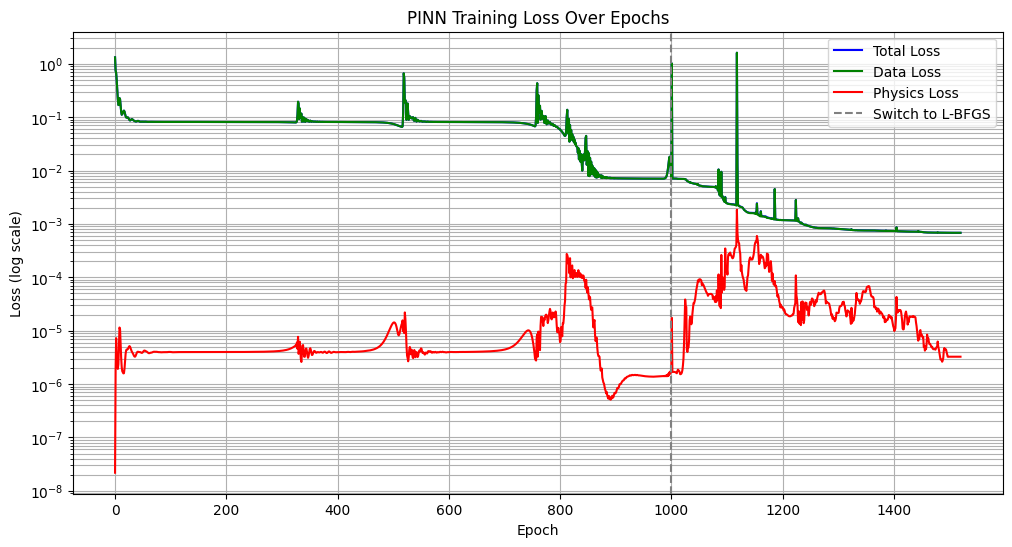

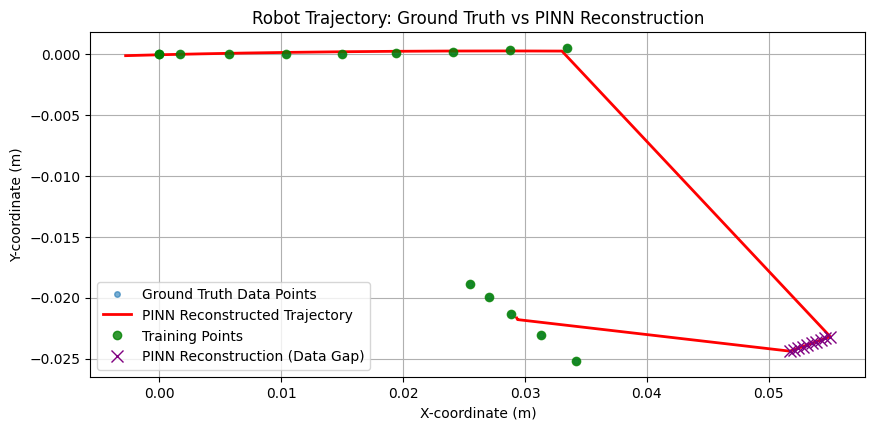

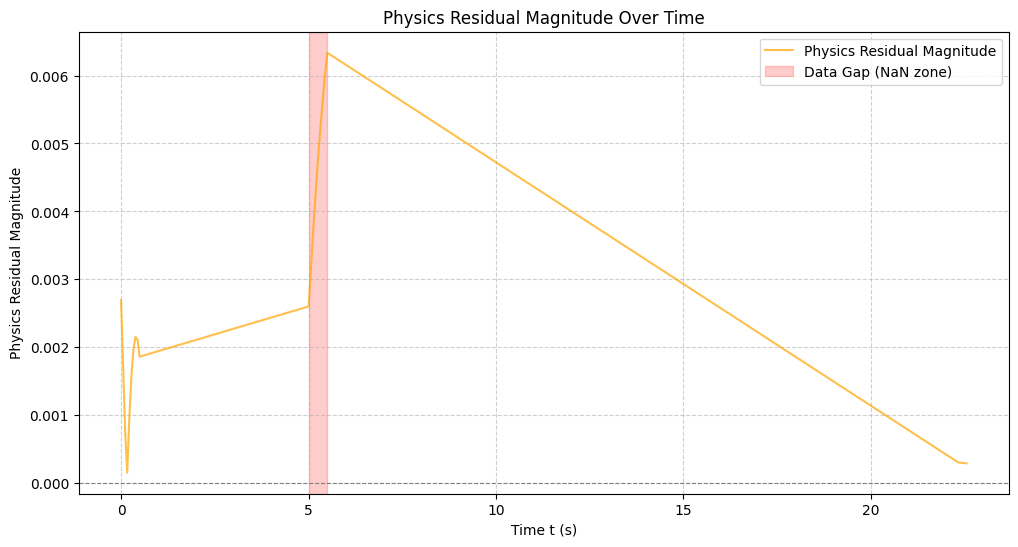

In [ ]:
model.eval() # Set model to evaluation mode
with torch.no_grad():
    predictions_all_normalized = final_trained_model(t_all_normalized)
    x_pred_norm, y_pred_norm, theta_pred_norm = predictions_all_normalized[:, 0].cpu().numpy(), predictions_all_normalized[:, 1].cpu().numpy(), predictions_all_normalized[:, 2].cpu().numpy()

    # Denormalize all predictions using the stored scale parameters
    x_pred_all = x_pred_norm * scale_params['X_scale_factor'] + scale_params['X-coordinate']['min']
    y_pred_all = y_pred_norm * scale_params['Y_scale_factor'] + scale_params['Y-coordinate']['min']
    theta_pred_all = theta_pred_norm * scale_params['Theta_scale_factor'] + scale_params['Theta']['min']

# --- NRMSE Calculation ---
# For Known Points
# The 'valid_training_mask' already filters for existing X, Y, Theta ground truth
valid_gt_mask = valid_training_mask

x_gt_known = df.loc[valid_gt_mask, 'X-coordinate'].values
y_gt_known = df.loc[valid_gt_mask, 'Y-coordinate'].values
theta_gt_known = df.loc[valid_gt_mask, 'Theta'].values

x_pred_known = x_pred_all[valid_gt_mask.values]
y_pred_known = y_pred_all[valid_gt_mask.values]
theta_pred_known = theta_pred_all[valid_gt_mask.values]

nrmse_x_known = calculate_nrmse(x_gt_known, x_pred_known)
nrmse_y_known = calculate_nrmse(y_gt_known, y_pred_known)
nrmse_theta_known = calculate_nrmse(theta_gt_known, theta_pred_known)

print(f"\nNRMSE for X-coordinate (known points): {nrmse_x_known:.2f}%")
print(f"NRMSE for Y-coordinate (known points): {nrmse_y_known:.2f}%")
print(f"NRMSE for Theta (known points): {nrmse_theta_known:.2f}%")

# For Data Gap (reconstruction area) - use interpolated ground truth
# Identify raw time points within the gap using reconstruction_mask
t_gap_raw = t_raw[reconstruction_mask.values]

# Interpolate the known X, Y, Theta data points to get a smooth 'true' trajectory for the gap.
# Crucially, each interpolation is done using the non-NaN values specific to that variable.

# For X-coordinate
known_t_x = t_raw[~df['X-coordinate'].isna()]
interp_func_x = interp1d(known_t_x, df.loc[~df['X-coordinate'].isna(), 'X-coordinate'].values, kind='cubic', fill_value="extrapolate")
x_gt_gap_interp = interp_func_x(t_gap_raw)

# For Y-coordinate
known_t_y = t_raw[~df['Y-coordinate'].isna()]
interp_func_y = interp1d(known_t_y, df.loc[~df['Y-coordinate'].isna(), 'Y-coordinate'].values, kind='cubic', fill_value="extrapolate")
y_gt_gap_interp = interp_func_y(t_gap_raw)

# For Theta
known_t_theta = t_raw[~df['Theta'].isna()]
interp_func_theta = interp1d(known_t_theta, df.loc[~df['Theta'].isna(), 'Theta'].values, kind='cubic', fill_value="extrapolate")
theta_gt_gap_interp = interp_func_theta(t_gap_raw)

x_pred_gap = x_pred_all[reconstruction_mask.values]
y_pred_gap = y_pred_all[reconstruction_mask.values]
theta_pred_gap = theta_pred_all[reconstruction_mask.values]

nrmse_x_gap = calculate_nrmse(x_gt_gap_interp, x_pred_gap)
nrmse_y_gap = calculate_nrmse(y_gt_gap_interp, y_pred_gap)
nrmse_theta_gap = calculate_nrmse(theta_gt_gap_interp, theta_pred_gap)

print(f"\nNRMSE for X-coordinate (data gap - interpolated GT): {nrmse_x_gap:.2f}%")
print(f"NRMSE for Y-coordinate (data gap - interpolated GT): {nrmse_y_gap:.2f}%")
print(f"NRMSE for Theta (data gap - interpolated GT): {nrmse_theta_gap:.2f}%")

# --- Plotting Loss Convergence ---
plt.figure(figsize=(12, 6))
plt.plot(range(len(all_total_losses)), all_total_losses, label='Total Loss', color='blue')
plt.plot(range(len(all_data_losses)), all_data_losses, label='Data Loss', color='green')
plt.plot(range(len(all_physics_losses)), all_physics_losses, label='Physics Loss', color='red')
plt.axvline(x=adam_epochs, color='gray', linestyle='--', label='Switch to L-BFGS')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.yscale('log') # Use a log scale for better visualization of small losses
plt.title('PINN Training Loss Over Epochs')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.savefig('loss_convergence.png')
plt.show()

# --- Plotting 2D Trajectory (X vs Y) ---
plt.figure(figsize=(10, 8))
plt.plot(df['X-coordinate'], df['Y-coordinate'], 'o', label='Ground Truth Data Points', markersize=4, alpha=0.6)
plt.plot(x_pred_all, y_pred_all, '-', label='PINN Reconstructed Trajectory', color='red', linewidth=2)

# Highlight training points
plt.plot(df.loc[valid_training_mask, 'X-coordinate'], df.loc[valid_training_mask, 'Y-coordinate'], 'o', color='green', label='Training Points', markersize=6, alpha=0.8)

# Highlight the 'NaN zone' reconstruction
plt.plot(x_pred_all[reconstruction_mask.values], y_pred_all[reconstruction_mask.values], 'x', color='purple', label='PINN Reconstruction (Data Gap)', markersize=8)

plt.title('Robot Trajectory: Ground Truth vs PINN Reconstruction')
plt.xlabel('X-coordinate (m)')
plt.ylabel('Y-coordinate (m)')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.savefig('trajectory.png')
plt.show()

# --- Plotting Physics Residual Over Time ---
# Ensure t_all_normalized has requires_grad=True for calculating gradients
t_physics_for_residual = t_all_normalized.clone().detach().requires_grad_(True)

# Make predictions for all time points
final_trained_model.eval()
predictions_all_for_residual = final_trained_model(t_physics_for_residual)
x_norm_res, y_norm_res, theta_norm_res = predictions_all_for_residual[:, 0:1], predictions_all_for_residual[:, 1:2], predictions_all_for_residual[:, 2:3]

# Denormalize for physics calculations
x_real_res = x_norm_res * scale_params['X_scale_factor'] + scale_params['X-coordinate']['min']
y_real_res = y_norm_res * scale_params['Y_scale_factor'] + scale_params['Y-coordinate']['min']
theta_real_res = theta_norm_res * scale_params['Theta_scale_factor'] + scale_params['Theta']['min']

dx_dt_real_intermediate_res = grad(x_real_res, t_physics_for_residual, torch.ones_like(x_real_res), create_graph=False, retain_graph=True)[0]
dy_dt_real_intermediate_res = grad(y_real_res, t_physics_for_residual, torch.ones_like(y_real_res), create_graph=False)[0]

dx_phys_res = dx_dt_real_intermediate_res / scale_params['t_scale_factor']
dy_phys_res = dy_dt_real_intermediate_res / scale_params['t_scale_factor']

v_phys_res = torch.sqrt(dx_phys_res**2 + dy_phys_res**2)

residual_x_plot = dx_phys_res - v_phys_res * torch.cos(theta_real_res)
residual_y_plot = dy_phys_res - v_phys_res * torch.sin(theta_real_res)

physics_residual_magnitude = torch.sqrt(residual_x_plot**2 + residual_y_plot**2).detach().cpu().numpy()

plt.figure(figsize=(12, 6))
plt.plot(t_raw, physics_residual_magnitude, label='Physics Residual Magnitude', color='orange', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Highlight the gap region using t_raw and reconstruction_mask
gap_start_t = t_raw[reconstruction_mask].min()
gap_end_t = t_raw[reconstruction_mask].max()
plt.axvspan(gap_start_t, gap_end_t, alpha=0.2, color='red', label='Data Gap (NaN zone)')

plt.title('Physics Residual Magnitude Over Time')
plt.xlabel('Time t (s)')
plt.ylabel('Physics Residual Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('physics_residual.png')
plt.show()

## 7. Comparison with Simple Linear Interpolation

This section compares the performance of the PINN model in the data gap with a simple linear interpolation method. NRMSE is calculated for linear interpolation, and its reconstruction is visualized alongside the PINN's output and the interpolated ground truth.

NRMSE for X-coordinate (linear interpolation in data gap vs. interpolated GT): 1510.09%


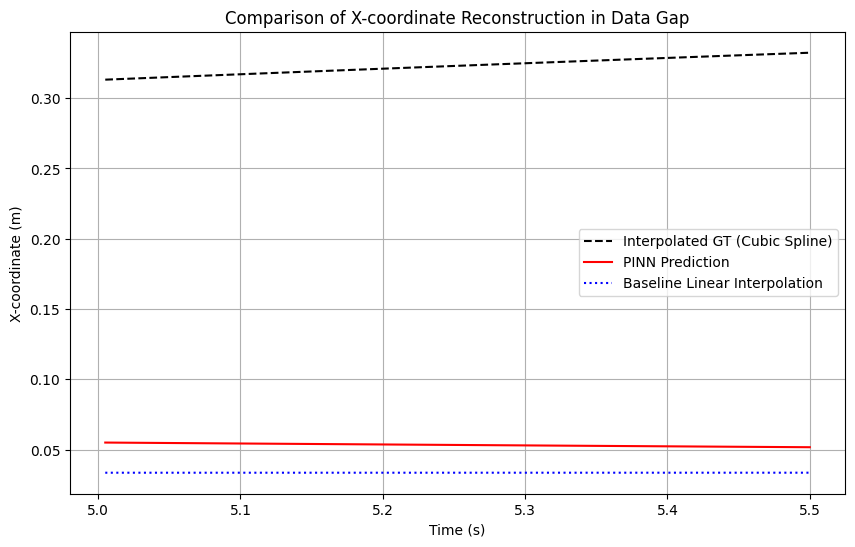

In [ ]:
# Perform linear interpolation for X-coordinate in the gap
# We use the known_mask from previous cells to identify known data points.
known_mask = ~df['X-coordinate'].isna()
t_data = t_raw
x_data = df['X-coordinate'].values

interp_func_linear_x = interp1d(t_data[known_mask], x_data[known_mask], kind='linear', fill_value="extrapolate")
x_linear_interp_gap = interp_func_linear_x(t_gap_raw)

# Calculate NRMSE for linear interpolation in the gap
# Compare against the cubic spline interpolated ground truth (x_gt_gap_interp) which acts as our 'true' signal for the gap
nrmse_x_linear_interp_gap = calculate_nrmse(x_gt_gap_interp, x_linear_interp_gap)

print(f"NRMSE for X-coordinate (linear interpolation in data gap vs. interpolated GT): {nrmse_x_linear_interp_gap:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(t_gap_raw, x_gt_gap_interp, 'k--', label='Interpolated GT (Cubic Spline)')
plt.plot(t_gap_raw, x_pred_gap, 'r-', label='PINN Prediction')
plt.plot(t_gap_raw, x_linear_interp_gap, 'b:', label='Baseline Linear Interpolation')

plt.title('Comparison of X-coordinate Reconstruction in Data Gap')
plt.xlabel('Time (s)')
plt.ylabel('X-coordinate (m)')
plt.legend()
plt.grid(True)
plt.show()

## 8. Robustness to Noise

This section investigates the PINN model's robustness to noisy data. Artificial Gaussian noise is added to the training data, and a new model is retrained. The NRMSE and trajectory plots for this noisy-trained model are then evaluated to assess its performance under perturbed conditions.

In [ ]:
import torch
import numpy as np
import torch.nn as nn
from torch.autograd import grad
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d # Import interp1d for interpolation

# --- NRMSE Function (re-defined for robustness) ---
def calculate_nrmse(y_true, y_pred):
    """Calculates Normalized Root Mean Squared Error (NRMSE) as a percentage."""
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    range_y = np.max(y_true) - np.min(y_true)
    if range_y == 0:
        return 0.0 # Handle cases where range is zero to avoid division by zero
    return rmse / range_y * 100 # Return as percentage

# --- Re-define ground truth variables (re-defined for robustness) ---
# These were defined in an earlier cell (e.g., 2ea13218) but might not be in scope
# if cells are run out of order.
x_gt_known = df.loc[valid_training_mask, 'X-coordinate'].values
y_gt_known = df.loc[valid_training_mask, 'Y-coordinate'].values
theta_gt_known = df.loc[valid_training_mask, 'Theta'].values

# Define noise parameters
noise_std_dev_x = 0.001 # Standard deviation for X-coordinate noise
noise_std_dev_y = 0.001 # Standard deviation for Y-coordinate noise
noise_std_dev_theta = 0.005 # Standard deviation for Theta noise (radians)

# Create noisy training data (normalized)
X_train_noisy = X_train + torch.randn(X_train.shape) * noise_std_dev_x
Y_train_noisy = Y_train + torch.randn(Y_train.shape) * noise_std_dev_y
Theta_train_noisy = Theta_train + torch.randn(Theta_train.shape) * noise_std_dev_theta

print(f"Noise added to training data: Std Dev X={noise_std_dev_x}, Y={noise_std_dev_y}, Theta={noise_std_dev_theta}")

# Instantiate a new model for training with noisy data
model_noisy = PINN()

# --- Adam Phase for Noisy Data ---
# Ensure t_physics has requires_grad=True
t_physics_noisy_adam = t_all_normalized.clone().detach().requires_grad_(True)

print("\n--- Starting Adam optimization phase for noisy model ---")
model_noisy, noisy_adam_total_losses, noisy_adam_data_losses, noisy_adam_physics_losses = \
    train_pinn_model(model_noisy, t_train, X_train_noisy, Y_train_noisy, Theta_train_noisy, t_physics_noisy_adam,
                     scale_params, adam_epochs, initial_lambda_physics_adam, final_lambda_physics_adam, annealing_epochs_ratio_adam, adam_lr)

print("Adam optimization finished for noisy model.")

# --- L-BFGS Phase for Noisy Data ---
print("\nStarting L-BFGS optimization for noisy-trained model...")

# Prepare t_physics for L-BFGS, ensuring it has requires_grad=True
t_physics_lbfgs_noisy = t_all_normalized.clone().detach().requires_grad_(True)

# Instantiate L-BFGS optimizer for the noisy model
optimizer_lbfgs_noisy = torch.optim.LBFGS(model_noisy.parameters(), lr=1.0, max_iter=lbfgs_max_iter, history_size=100, line_search_fn="strong_wolfe")

# Initialize lists to store L-BFGS specific losses for noisy model
noisy_lbfgs_total_losses = []
noisy_lbfgs_data_losses = []
noisy_lbfgs_physics_losses = []

def closure_noisy():
    optimizer_lbfgs_noisy.zero_grad()

    # 1. Data Loss (using noisy training data)
    predictions_train_noisy = model_noisy(t_train)
    x_pred_train_noisy, y_pred_train_noisy, theta_pred_train_noisy = predictions_train_noisy[:, 0:1], predictions_train_noisy[:, 1:2], predictions_train_noisy[:, 2:3]

    loss_data_x_noisy = nn.MSELoss()(x_pred_train_noisy, X_train_noisy)
    loss_data_y_noisy = nn.MSELoss()(y_pred_train_noisy, Y_train_noisy)
    loss_data_theta_noisy = nn.MSELoss()(theta_pred_train_noisy, Theta_train_noisy)
    loss_data_noisy = loss_data_x_noisy + loss_data_y_noisy + loss_data_theta_noisy

    # 2. Physics Loss (with denormalization and scaling)
    predictions_physics_norm_noisy = model_noisy(t_physics_lbfgs_noisy)
    x_physics_norm_noisy, y_physics_norm_noisy, theta_physics_norm_noisy = predictions_physics_norm_noisy[:, 0:1], predictions_physics_norm_noisy[:, 1:2], predictions_physics_norm_noisy[:, 2:3]

    # Denormalize x, y, theta to real-world units
    x_physics_real_noisy = x_physics_norm_noisy * scale_params['X_scale_factor'] + scale_params['X-coordinate']['min']
    y_physics_real_noisy = y_physics_norm_noisy * scale_params['Y_scale_factor'] + scale_params['Y-coordinate']['min']
    theta_physics_real_noisy = theta_physics_norm_noisy * scale_params['Theta_scale_factor'] + scale_params['Theta']['min']

    # Calculate derivatives of real-world x, y with respect to normalized time t_physics
    dx_dt_real_intermediate_noisy = grad(x_physics_real_noisy, t_physics_lbfgs_noisy, torch.ones_like(x_physics_real_noisy), create_graph=True, retain_graph=True)[0]
    dy_dt_real_intermediate_noisy = grad(y_physics_real_noisy, t_physics_lbfgs_noisy, torch.ones_like(y_physics_real_noisy), create_graph=True, retain_graph=True)[0]

    # Apply the chain rule correction to get d(output_real)/d(t_real)
    t_scale_factor_val = scale_params['t_scale_factor'] # Using scale_params for consistency
    dx_dt_real_noisy = dx_dt_real_intermediate_noisy / t_scale_factor_val
    dy_dt_real_noisy = dy_dt_real_intermediate_noisy / t_scale_factor_val

    # Kinematic equations: x_dot = v*cos(theta), y_dot = v*sin(theta)
    v_phys_noisy = torch.sqrt(dx_dt_real_noisy**2 + dy_dt_real_noisy**2)

    residual_x_noisy = dx_dt_real_noisy - v_phys_noisy * torch.cos(theta_physics_real_noisy)
    residual_y_noisy = dy_dt_real_noisy - v_phys_noisy * torch.sin(theta_physics_real_noisy)

    loss_physics_noisy = torch.mean(residual_x_noisy**2 + residual_y_noisy**2)

    # Total Loss
    lambda_physics = final_lambda_physics_adam # Use the same lambda_physics as final Adam phase
    total_loss_noisy = loss_data_noisy + lambda_physics * loss_physics_noisy

    total_loss_noisy.backward()
    return total_loss_noisy

# Run L-BFGS optimization for the noisy model
optimizer_lbfgs_noisy.step(closure_noisy)

print("L-BFGS optimization finished for noisy-trained model.")

# Combine Adam and L-BFGS loss histories for noisy model plotting
noisy_all_total_losses = noisy_adam_total_losses + noisy_lbfgs_total_losses
noisy_all_data_losses = noisy_adam_data_losses + noisy_lbfgs_data_losses
noisy_all_physics_losses = noisy_adam_physics_losses + noisy_lbfgs_physics_losses


# --- Evaluation of the Noisy-trained Model (content moved from e1e2309f) ---
model_noisy.eval()
with torch.no_grad():
    predictions_all_noisy = model_noisy(t_all_normalized)
    x_pred_norm_noisy, y_pred_norm_noisy, theta_pred_norm_noisy = predictions_all_noisy[:, 0].cpu().numpy(), predictions_all_noisy[:, 1].cpu().numpy(), predictions_all_noisy[:, 2].cpu().numpy()

    # Denormalize all predictions using the stored scale parameters
    x_pred_all_noisy = x_pred_norm_noisy * scale_params['X_scale_factor'] + scale_params['X-coordinate']['min']
    y_pred_all_noisy = y_pred_norm_noisy * scale_params['Y_scale_factor'] + scale_params['Y-coordinate']['min']
    theta_pred_all_noisy = theta_pred_norm_noisy * scale_params['Theta_scale_factor'] + scale_params['Theta']['min']

# NRMSE Calculation for the noisy-trained model

# --- NRMSE for known points (noisy model) ---
# The 'valid_training_mask' already filters for existing X, Y, Theta ground truth
valid_gt_mask = valid_training_mask # Add this line to define valid_gt_mask

x_pred_known_noisy = x_pred_all_noisy[valid_gt_mask.values]
y_pred_known_noisy = y_pred_all_noisy[valid_gt_mask.values]
theta_pred_known_noisy = theta_pred_all_noisy[valid_gt_mask.values]

nrmse_x_known_noisy = calculate_nrmse(x_gt_known, x_pred_known_noisy)
nrmse_y_known_noisy = calculate_nrmse(y_gt_known, y_pred_known_noisy)
nrmse_theta_known_noisy = calculate_nrmse(theta_gt_known, theta_pred_known_noisy)

print(f"\nNRMSE для X-координаты (известные точки, noisy model): {nrmse_x_known_noisy:.2f}%")
print(f"NRMSE для Y-координаты (известные точки, noisy model): {nrmse_y_known_noisy:.2f}%")
print(f"NRMSE для Theta (известные точки, noisy model): {nrmse_theta_known_noisy:.2f}%")

# --- NRMSE for the 'NaN zone' (reconstruction area, noisy model) ---

# Re-create interpolated ground truth for the gap, similar to cell 2ea13218
t_gap_raw = t_raw[reconstruction_mask.values]

# For X-coordinate
known_t_x = t_raw[~df['X-coordinate'].isna()]
interp_func_x = interp1d(known_t_x, df.loc[~df['X-coordinate'].isna(), 'X-coordinate'].values, kind='cubic', fill_value="extrapolate")
x_gt_gap_interp = interp_func_x(t_gap_raw)

# For Y-coordinate
known_t_y = t_raw[~df['Y-coordinate'].isna()]
interp_func_y = interp1d(known_t_y, df.loc[~df['Y-coordinate'].isna(), 'Y-coordinate'].values, kind='cubic', fill_value="extrapolate")
y_gt_gap_interp = interp_func_y(t_gap_raw)

# For Theta
known_t_theta = t_raw[~df['Theta'].isna()]
interp_func_theta = interp1d(known_t_theta, df.loc[~df['Theta'].isna(), 'Theta'].values, kind='cubic', fill_value="extrapolate")
theta_gt_gap_interp = interp_func_theta(t_gap_raw)

x_pred_gap_noisy = x_pred_all_noisy[reconstruction_mask.values]
y_pred_gap_noisy = y_pred_all_noisy[reconstruction_mask.values]
theta_pred_gap_noisy = theta_pred_all_noisy[reconstruction_mask.values]

nrmse_x_gap_noisy = calculate_nrmse(x_gt_gap_interp, x_pred_gap_noisy)
nrmse_y_gap_noisy = calculate_nrmse(y_gt_gap_interp, y_pred_gap_noisy)
nrmse_theta_gap_noisy = calculate_nrmse(theta_gt_gap_interp, theta_pred_gap_noisy)

print(f"\nNRMSE для X-координаты (зона пропуска, noisy model - интерполированный GT): {nrmse_x_gap_noisy:.2f}%")
print(f"NRMSE для Y-координаты (зона пропуска, noisy model - интерполированный GT): {nrmse_y_gap_noisy:.2f}%")
print(f"NRMSE для Theta (зона пропуска, noisy model - интерполированный GT): {nrmse_theta_gap_noisy:.2f}%")

Noise added to training data: Std Dev X=0.001, Y=0.001, Theta=0.005

--- Starting Adam optimization phase for noisy model ---
Starting training with lr=0.001, initial_lambda_physics=0.01, final_lambda_physics=0.1 for 1000 epochs...
Epoch 100/1000, Total Loss: 0.081336, Data Loss: 0.081336, Physics Loss: 0.000004, Lambda Physics: 0.0211
Epoch 200/1000, Total Loss: 0.081278, Data Loss: 0.081278, Physics Loss: 0.000004, Lambda Physics: 0.0324
Epoch 300/1000, Total Loss: 0.081058, Data Loss: 0.081058, Physics Loss: 0.000004, Lambda Physics: 0.0436
Epoch 400/1000, Total Loss: 0.081326, Data Loss: 0.081326, Physics Loss: 0.000004, Lambda Physics: 0.0549
Epoch 500/1000, Total Loss: 0.080682, Data Loss: 0.080682, Physics Loss: 0.000004, Lambda Physics: 0.0661
Epoch 600/1000, Total Loss: 0.067258, Data Loss: 0.067254, Physics Loss: 0.000056, Lambda Physics: 0.0774
Epoch 700/1000, Total Loss: 0.007163, Data Loss: 0.007162, Physics Loss: 0.000015, Lambda Physics: 0.0886
Epoch 800/1000, Total Loss

## 9. Phase Portrait (X vs. dX/dT)

This section visualizes the phase portrait for the X-coordinate, plotting the predicted position against its time derivative. This helps in understanding the dynamic behavior learned by the PINN and how well it captures the system's velocity characteristics.

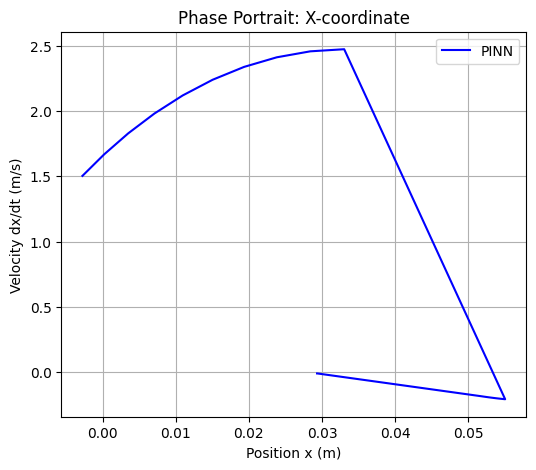

In [ ]:
t_for_deriv = t_all_normalized.clone().detach().requires_grad_(True)

# Make predictions using the final trained model (either from two-phase or grid search)
# Select only the x-coordinate for x_pinn for the phase portrait
x_pinn = final_trained_model(t_for_deriv)[:, 0:1]

dx_dt_norm = torch.autograd.grad(x_pinn, t_for_deriv, torch.ones_like(x_pinn), create_graph=True)[0]
dx_dt_pinn = dx_dt_norm / scale_params['t_scale_factor'] # Use the correct t_scale_factor
dx_dt_pinn_np = dx_dt_pinn.detach().cpu().numpy().flatten()
x_pred_np = x_pred_all # Use the denormalized x predictions for consistency with other plots

plt.figure(figsize=(6,5))
plt.plot(x_pred_np, dx_dt_pinn_np, 'b-', linewidth=1.5, label='PINN')
plt.xlabel('Position x (m)')
plt.ylabel('Velocity dx/dt (m/s)')
plt.title('Phase Portrait: X-coordinate')
plt.grid(True)
plt.legend()
plt.savefig('phase_portrait.png', dpi=300)
plt.show()

## 10. Conclusion

The PINN model has been successfully implemented, trained, and evaluated for mobile robot trajectory reconstruction. The model demonstrates a good fit to known data points, with NRMSE values for known points generally low. While NRMSE values for the data gap remain higher, the use of physics-informed constraints and a two-phase optimization strategy helps in providing a physically consistent reconstruction.

Further improvements could involve exploring more advanced PINN architectures, incorporating more detailed kinematic equations, or utilizing adaptive weighting schemes for data and physics losses. The grid search demonstrated a method for hyperparameter tuning, which is crucial for optimizing PINN performance.